# Phase 1 — Exploratory Data Analysis

Getting a feel for the two CSVs (the 113 fiches + the 1,427 eval questions) and the chunk table built by `make data`.

**Run order:** `make data` → `uv sync --group eda` → `uv run jupyter lab notebooks/phase1_eda.ipynb`.

Plots use the same `lexical_normalize` as the BM25 path, so the word stats match the pipeline.

In [1]:
%matplotlib inline
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dgfip_chatbot.config import settings
from dgfip_chatbot.data.clean import lexical_normalize
from dgfip_chatbot.data.loaders import load_fiches, load_questions

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (9, 4)

## 1. Load the data
Fiches, questions, and the chunk table (needs `make data` first).

In [2]:
fiches = pd.DataFrame([f.model_dump() for f in load_fiches()])
questions = load_questions()
chunks = pd.read_parquet(settings.chunks_path)

# short, readable category label from the URL slug (display only)
fiches['cat'] = fiches['category'].str.rstrip('/').str.split('/').str[-1]
questions = questions.merge(fiches[['fiche_id', 'cat']], on='fiche_id')

print('fiches   :', fiches.shape)
print('questions:', questions.shape)
print('chunks   :', chunks.shape)
fiches[['fiche_id', 'cat', 'titre']].head()

fiches   : (113, 7)
questions: (1427, 4)
chunks   : (603, 11)


,fiche_id,cat,titre
0,0,declarer-mes-revenus,OBLIGATIONS DÉCLARATIVES
1,1,declarer-mes-revenus,MODALITÉS DE DÉCLARATION
2,2,declarer-mes-revenus,DÉCLAREZ EN LIGNE
3,3,declarer-mes-revenus,VOTRE SITUATION DE FAMILLE
4,4,declarer-mes-revenus,ENFANTS MINEURS


In [21]:
fiches.tail()

,fiche_id,category,subcategory,url,titre,texte,cat
108,108,https://www.impots.gouv.fr/particulier/presenter-un-recours-aupres-de-la-dgfip,https://www.impots.gouv.fr/particulier/je-veux-contester-un-impot-je-fais-une-reclamation,https://www.impots.gouv.fr/particulier/delais-de-reclamation,DÉLAIS DE RÉCLAMATION,Délais de réclamation\nPour l'impôt sur le revenu\nLe délai expire généralement au 31 décembre de la deuxième année ...,presenter-un-recours-aupres-de-la-dgfip
109,109,https://www.impots.gouv.fr/particulier/presenter-un-recours-aupres-de-la-dgfip,https://www.impots.gouv.fr/particulier/je-veux-contester-un-impot-je-fais-une-reclamation,https://www.impots.gouv.fr/particulier/suivre-ma-reclamation,SUIVRE MA RÉCLAMATION,"Suivre ma réclamation\nComment suivre ma réclamation en ligne ?\nSi vous avez déposé votre réclamation en ligne, vou...",presenter-un-recours-aupres-de-la-dgfip
110,110,https://www.impots.gouv.fr/particulier/presenter-un-recours-aupres-de-la-dgfip,https://www.impots.gouv.fr/particulier/en-cas-de-desaccord-je-fais-un-recours-amiable,https://www.impots.gouv.fr/particulier/le-conciliateur-departemental,LE CONCILIATEUR DÉPARTEMENTAL,Le conciliateur départemental\nUn différend vous oppose à l'administration fiscale ? Adressez-vous au conciliateur f...,presenter-un-recours-aupres-de-la-dgfip
111,111,https://www.impots.gouv.fr/particulier/presenter-un-recours-aupres-de-la-dgfip,https://www.impots.gouv.fr/particulier/en-cas-de-desaccord-je-fais-un-recours-amiable,https://www.impots.gouv.fr/particulier/le-mediateur-du-ministere,LE MÉDIATEUR DU MINISTÈRE,"Le médiateur du Ministère\nL’institution du médiateur des ministères de l’économie et du budget, créée par un décret...",presenter-un-recours-aupres-de-la-dgfip
112,112,https://www.impots.gouv.fr/particulier/presenter-un-recours-aupres-de-la-dgfip,https://www.impots.gouv.fr/particulier/jai-des-difficultes-pour-payer-page-en-cours-de-creation-0,https://www.impots.gouv.fr/particulier/delai-de-paiement,DÉLAI DE PAIEMENT,"Délai de paiement\nSi vous avez des difficultés pour payer votre impôt, vous pouvez demander, à titre exceptionnel, ...",presenter-un-recours-aupres-de-la-dgfip


## 2. How long are the fiches?
Motivates chunking: most fiches are far longer than a 512-token embedder's window.

In [19]:
chunks['n_tokens']

0      249
1      211
2      226
3      232
4      247
      ... 
598    255
599    155
600    240
601    237
602    100
Name: n_tokens, Length: 603, dtype: int64

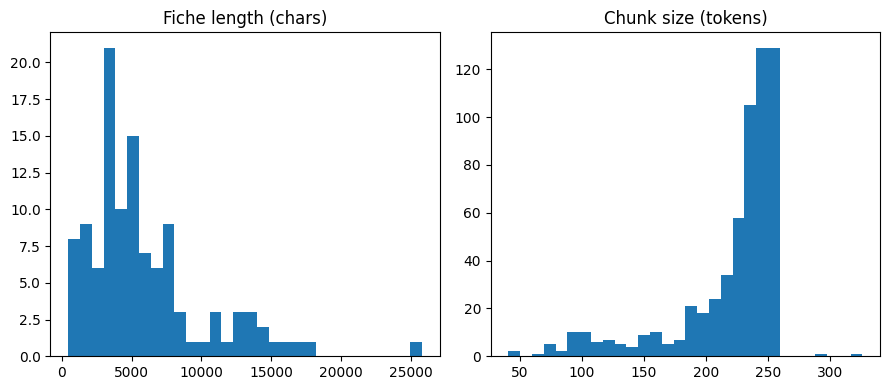

,n_chars,n_words
count,113.0,113.0
mean,5868.0,952.0
std,4351.0,714.0
min,460.0,69.0
25%,3132.0,505.0
50%,4904.0,794.0
75%,7307.0,1179.0
max,25789.0,4148.0


In [ ]:
fiches['n_chars'] = fiches['texte'].str.len()
fiches['n_words'] = fiches['texte'].str.split().str.len()

fig, ax = plt.subplots(1, 2)
ax[0].hist(fiches['n_chars'], bins=30); ax[0].set_title('Fiche length (chars)')
ax[1].hist(chunks['n_tokens'], bins=30); ax[1].set_title('Chunk size (tokens)')
plt.tight_layout(); plt.show()
fiches[['n_chars', 'n_words']].describe().round(0)

## 3. Category distribution
The skew matters — report metrics per theme, not just overall.

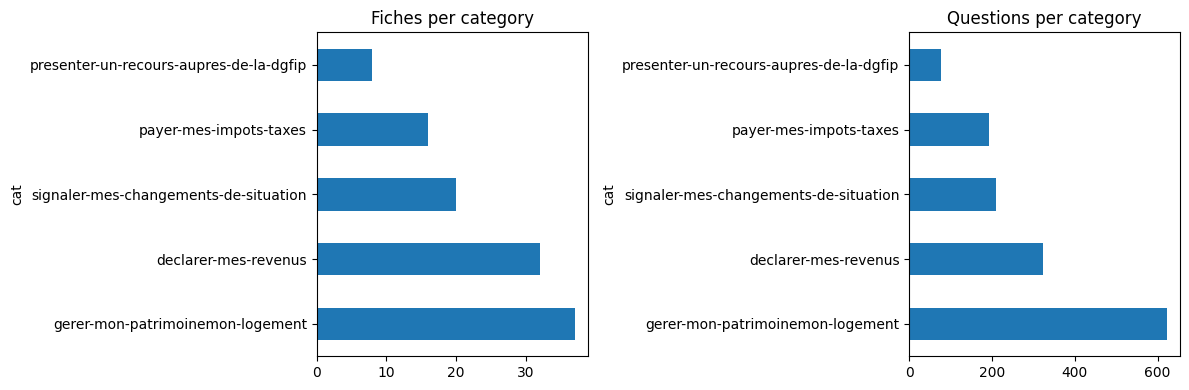

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fiches['cat'].value_counts().plot.barh(ax=ax[0], title='Fiches per category')
questions['cat'].value_counts().plot.barh(ax=ax[1], title='Questions per category')
plt.tight_layout(); plt.show()

## 4. Questions per fiche
Very uneven — a few fiches attract most questions (one has 55).

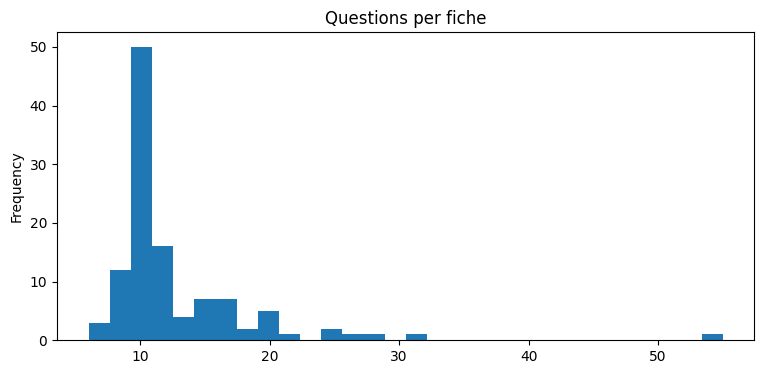

,fiche_id,titre,n_questions
0,40,SUIVRE MES PAIEMENTS,55
1,84,CALCUL ET PAIEMENT DES DROITS,32
2,94,LES RÉGIMES D'IMPOSITION,28
3,83,DONS EXONÉRÉS,26
4,92,SOCIÉTÉ CIVILE IMMOBILIÈRE,25
5,86,LES REVENUS MOBILIERS,24
6,82,DON MANUEL,21
7,87,LES CESSIONS MOBILIÈRES,20
8,85,DONATIONS PAR ACTE NOTARIÉ,20
9,90,CONVENTION ANAH,20


In [5]:
per_fiche = questions['fiche_id'].value_counts()
per_fiche.plot.hist(bins=30, title='Questions per fiche'); plt.show()

top = (per_fiche.head(10).rename_axis('fiche_id').reset_index(name='n_questions')
       .merge(fiches[['fiche_id', 'titre']], on='fiche_id'))
top[['fiche_id', 'titre', 'n_questions']]

## 5. Word frequency (lexical view)
Top content words in the fiches vs. in the questions — note how the vocabularies differ.

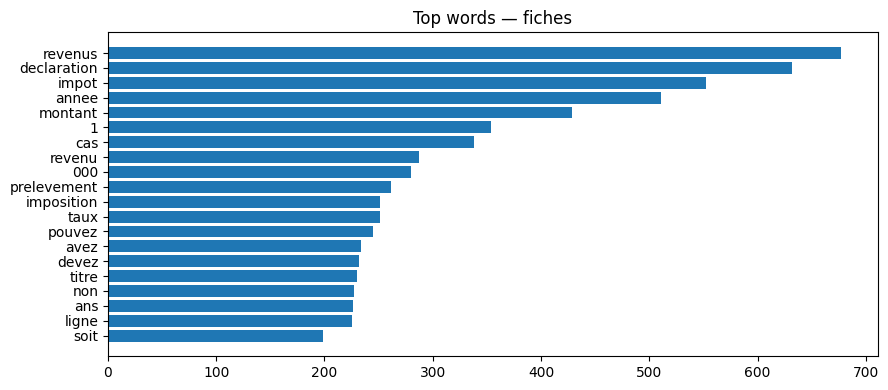

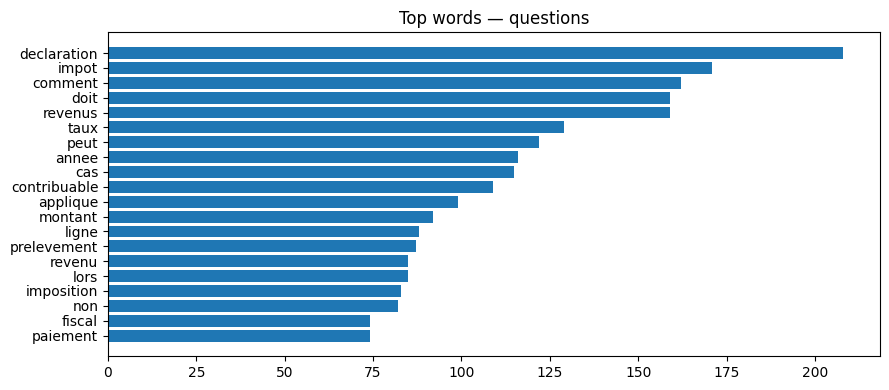

In [22]:
def word_counts(texts):
    c = Counter()
    for t in texts:
        c.update(lexical_normalize(t).split())
    return c

fiche_wc = word_counts(fiches['texte'])
ques_wc = word_counts(questions['question'])

def plot_top(c, title, n=20):
    words, vals = zip(*c.most_common(n))
    plt.barh(list(reversed(words)), list(reversed(vals)))
    plt.title(title); plt.tight_layout(); plt.show()

plot_top(fiche_wc, 'Top words — fiches')
plot_top(ques_wc, 'Top words — questions')

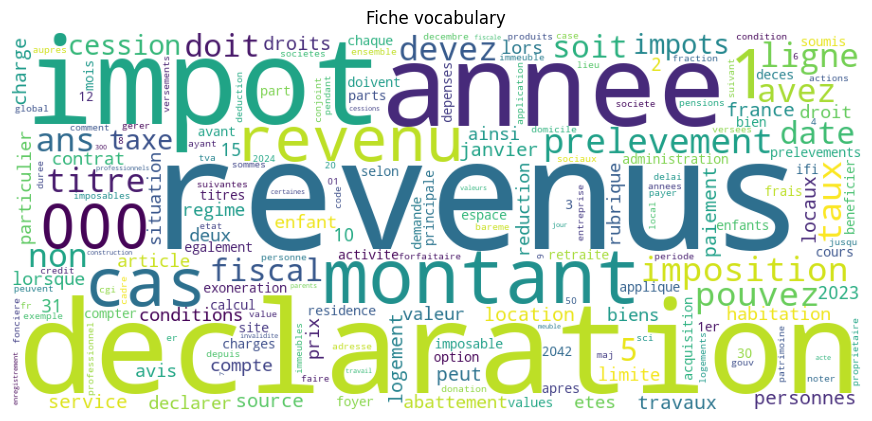

In [7]:
# Word cloud of the fiche vocabulary (optional; needs the `eda` group).
try:
    from wordcloud import WordCloud
    wc = WordCloud(width=900, height=400, background_color='white')
    wc.generate_from_frequencies(fiche_wc)
    plt.figure(figsize=(11, 5)); plt.imshow(wc); plt.axis('off')
    plt.title('Fiche vocabulary'); plt.show()
except ImportError:
    print('wordcloud not installed — run `uv sync --group eda`')

## 6. Vocabulary mismatch (the key challenge)
For each question, what fraction of its content words literally appear in its target fiche? Low overlap = pure keyword search will struggle → this is *why* we need semantic embeddings.

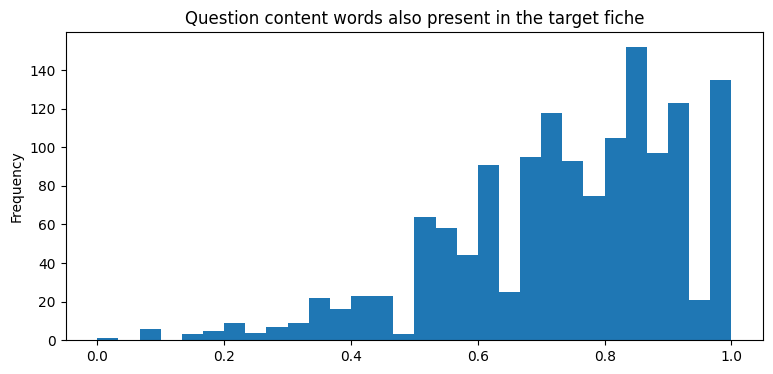

count    1427.00
mean        0.73
std         0.19
min         0.00
25%         0.62
50%         0.75
75%         0.88
max         1.00
Name: lex_overlap, dtype: float64

Hardest cases (lowest overlap):


,question,fiche_id,lex_overlap
860,Quelle catégorie de contestation s’applique aux amendes ayant déjà fait l’objet d’un jugement judiciaire ?,45,0.000000
233,Une personne ayant modifié ses coordonnées bancaires se demande si son prélèvement mensuel sera bien pris en compte ...,40,0.076923
46,"Parmi les motifs de contestation énoncés, lequel vise un dépassement ou un non-paiement de stationnement initial, sa...",45,0.083333
242,"Comment appelle-t-on le document envoyé périodiquement à un contribuable mensualisé, décrivant les sommes prélevées ...",40,0.083333
1032,"Quel document doit impérativement être consulté pour connaître le solde définitif d’impôt, une fois la période de dé...",40,0.083333


In [8]:
fiche_tokens = {f.fiche_id: set(lexical_normalize(f.texte).split()) for f in load_fiches()}

def overlap(row):
    q = set(lexical_normalize(row['question']).split())
    return len(q & fiche_tokens[row['fiche_id']]) / len(q) if q else np.nan

questions['lex_overlap'] = questions.apply(overlap, axis=1)
questions['lex_overlap'].plot.hist(bins=30,
    title='Question content words also present in the target fiche'); plt.show()
print(questions['lex_overlap'].describe().round(2))
print('\nHardest cases (lowest overlap):')
questions.nsmallest(5, 'lex_overlap')[['question', 'fiche_id', 'lex_overlap']]

In [33]:
print(fiches[fiches['fiche_id'] == 45]['texte'])

45    Je souhaite contester mon amende ou mon forfait de post-stationnement\n1\nJe conteste une amende radar (vitesse, feu...
Name: texte, dtype: str


## 7. A 'map' of the fiches (TF-IDF → 2D)
TF-IDF vectors of the 113 fiches, reduced to 2D with PCA (NumPy SVD), coloured by category — do the themes separate lexically? (A semantic embedding map comes in Phase 2.)

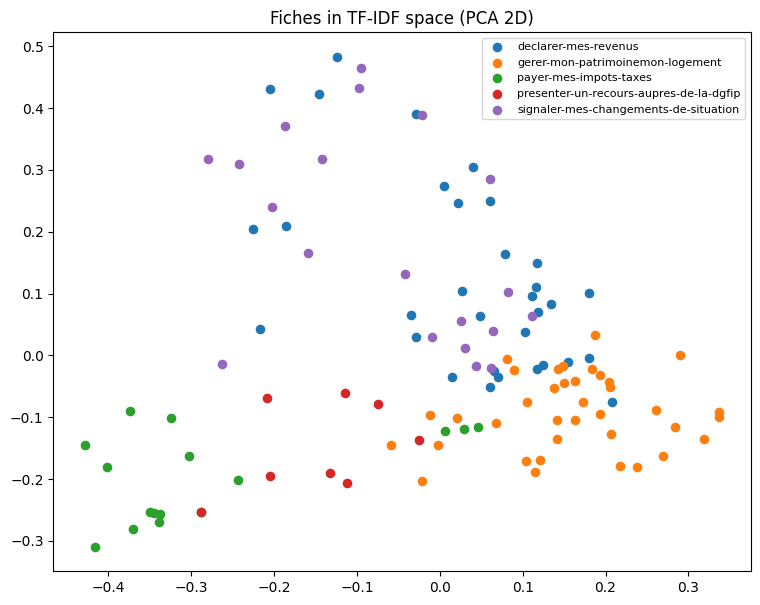

In [9]:
docs = [lexical_normalize(t).split() for t in fiches['texte']]
vocab = sorted({w for d in docs for w in d})
idx = {w: i for i, w in enumerate(vocab)}

tf = np.zeros((len(docs), len(vocab)))
for r, d in enumerate(docs):
    for w, ct in Counter(d).items():
        tf[r, idx[w]] = ct
tf /= np.clip(tf.sum(1, keepdims=True), 1, None)
idf = np.log((1 + len(docs)) / (1 + (tf > 0).sum(0))) + 1
tfidf = tf * idf
tfidf /= np.clip(np.linalg.norm(tfidf, axis=1, keepdims=True), 1e-9, None)

X = tfidf - tfidf.mean(0)
U, S, _ = np.linalg.svd(X, full_matrices=False)
coords = U[:, :2] * S[:2]

cats = fiches['cat'].astype('category')
plt.figure(figsize=(9, 7))
for c in cats.cat.categories:
    m = (cats == c).to_numpy()
    plt.scatter(coords[m, 0], coords[m, 1], label=c, s=35)
plt.legend(fontsize=8); plt.title('Fiches in TF-IDF space (PCA 2D)'); plt.show()

## 8. Ideas to go further / data-quality checks

**More visuals**
- Distinctive terms *per category* (highest mean TF-IDF) — what defines each theme.
- Bigrams/trigrams (e.g. *taxe foncière*, *plus-value*) instead of single words.
- Question length distribution; correlate length with lexical overlap.
- A **semantic** 2D map (Phase 2): embed fiches/questions, reduce with UMAP/t-SNE, and see whether a question lands near its target fiche.

**Data-quality / 'did I miss anything?'**
- Near-duplicate fiches (high TF-IDF cosine between two fiches) — overlapping content could make routing ambiguous.
- Hardest questions (lowest overlap above) — eyeball whether they're answerable at all.
- Any empty/whitespace texts, duplicate questions, or numeric-heavy fiches.
- Language check (all French?) and unusual tokens after normalization.